DataScience Mini Project- Solar Sense: Predicting Solar Energy Generation Using Weather Data
Sushma Karthikeyan(RA2311026050058), Deekshita Saravanan(RA2311026050031)

---



 STEP 1: Data Collection

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Plant_1_Generation_Data.csv to Plant_1_Generation_Data.csv


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Plant_1_Weather_Sensor_Data.csv to Plant_1_Weather_Sensor_Data.csv


 STEP 2: Load and View the Data

In [ ]:
import pandas as pd

# Load both datasets
gen_data = pd.read_csv('Plant_1_Generation_Data.csv')
weather_data = pd.read_csv('Plant_1_Weather_Sensor_Data.csv')

# View first few rows
print("Generation Data:")
print(gen_data.head())

print("\nWeather Data:")
print(weather_data.head())

Generation Data:
          DATE_TIME  PLANT_ID       SOURCE_KEY  DC_POWER  AC_POWER  \
0  15-05-2020 00:00   4135001  1BY6WEcLGh8j5v7       0.0       0.0   
1  15-05-2020 00:00   4135001  1IF53ai7Xc0U56Y       0.0       0.0   
2  15-05-2020 00:00   4135001  3PZuoBAID5Wc2HD       0.0       0.0   
3  15-05-2020 00:00   4135001  7JYdWkrLSPkdwr4       0.0       0.0   
4  15-05-2020 00:00   4135001  McdE0feGgRqW7Ca       0.0       0.0   

   DAILY_YIELD  TOTAL_YIELD  
0          0.0    6259559.0  
1          0.0    6183645.0  
2          0.0    6987759.0  
3          0.0    7602960.0  
4          0.0    7158964.0  

Weather Data:
             DATE_TIME  PLANT_ID       SOURCE_KEY  AMBIENT_TEMPERATURE  \
0  2020-05-15 00:00:00   4135001  HmiyD2TTLFNqkNe            25.184316   
1  2020-05-15 00:15:00   4135001  HmiyD2TTLFNqkNe            25.084589   
2  2020-05-15 00:30:00   4135001  HmiyD2TTLFNqkNe            24.935753   
3  2020-05-15 00:45:00   4135001  HmiyD2TTLFNqkNe            24.846130 

 STEP 3: Merge Both Datasets
  Why this is important:

 Generation data = power output

 Weather data = temperature, radiation

 We must combine them to train the model

In [ ]:
# Convert DATE_TIME to datetime format
gen_data['DATE_TIME'] = pd.to_datetime(gen_data['DATE_TIME'])
weather_data['DATE_TIME'] = pd.to_datetime(weather_data['DATE_TIME'])

# Merge datasets on DATE_TIME and PLANT_ID
merged_data = pd.merge(gen_data, weather_data, on=['DATE_TIME', 'PLANT_ID'])

# View merged data
print(merged_data.head())

   DATE_TIME  PLANT_ID     SOURCE_KEY_x  DC_POWER  AC_POWER  DAILY_YIELD  \
0 2020-05-15   4135001  1BY6WEcLGh8j5v7       0.0       0.0          0.0   
1 2020-05-15   4135001  1IF53ai7Xc0U56Y       0.0       0.0          0.0   
2 2020-05-15   4135001  3PZuoBAID5Wc2HD       0.0       0.0          0.0   
3 2020-05-15   4135001  7JYdWkrLSPkdwr4       0.0       0.0          0.0   
4 2020-05-15   4135001  McdE0feGgRqW7Ca       0.0       0.0          0.0   

   TOTAL_YIELD     SOURCE_KEY_y  AMBIENT_TEMPERATURE  MODULE_TEMPERATURE  \
0    6259559.0  HmiyD2TTLFNqkNe            25.184316           22.857507   
1    6183645.0  HmiyD2TTLFNqkNe            25.184316           22.857507   
2    6987759.0  HmiyD2TTLFNqkNe            25.184316           22.857507   
3    7602960.0  HmiyD2TTLFNqkNe            25.184316           22.857507   
4    7158964.0  HmiyD2TTLFNqkNe            25.184316           22.857507   

   IRRADIATION  
0          0.0  
1          0.0  
2          0.0  
3          0.0  
4

/tmp/ipykernel_10249/3583825648.py:2: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  gen_data['DATE_TIME'] = pd.to_datetime(gen_data['DATE_TIME'])


 STEP 4: Data Cleaning / Preprocessing (SOP Step 3)

4.1 Check Missing Values

In [ ]:
print(merged_data.isnull().sum())

DATE_TIME              0
PLANT_ID               0
SOURCE_KEY_x           0
DC_POWER               0
AC_POWER               0
DAILY_YIELD            0
TOTAL_YIELD            0
SOURCE_KEY_y           0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
IRRADIATION            0
dtype: int64


4.2 Handle Missing Values

In [ ]:
merged_data.fillna(method='ffill', inplace=True)

/tmp/ipykernel_10249/2235490398.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  merged_data.fillna(method='ffill', inplace=True)


4.3 Remove Duplicates

In [ ]:
merged_data.drop_duplicates(inplace=True)

 4.4 Convert Date Column (Feature Engineering)

In [ ]:
merged_data['HOUR'] = merged_data['DATE_TIME'].dt.hour
merged_data['DAY'] = merged_data['DATE_TIME'].dt.day
merged_data['MONTH'] = merged_data['DATE_TIME'].dt.month

4.5 Drop Unnecessary Columns

In [ ]:
merged_data.drop(columns=[col for col in merged_data.columns if 'SOURCE_KEY' in col], inplace=True)

In [ ]:
merged_data.head()

,DATE_TIME,PLANT_ID,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,HOUR,DAY,MONTH
0,2020-05-15,4135001,0.0,0.0,0.0,6259559.0,25.184316,22.857507,0.0,0,15,5
1,2020-05-15,4135001,0.0,0.0,0.0,6183645.0,25.184316,22.857507,0.0,0,15,5
2,2020-05-15,4135001,0.0,0.0,0.0,6987759.0,25.184316,22.857507,0.0,0,15,5
3,2020-05-15,4135001,0.0,0.0,0.0,7602960.0,25.184316,22.857507,0.0,0,15,5
4,2020-05-15,4135001,0.0,0.0,0.0,7158964.0,25.184316,22.857507,0.0,0,15,5


In [ ]:
print(merged_data.head())
print(merged_data.info())

   DATE_TIME  PLANT_ID  DC_POWER  AC_POWER  DAILY_YIELD  TOTAL_YIELD  \
0 2020-05-15   4135001       0.0       0.0          0.0    6259559.0   
1 2020-05-15   4135001       0.0       0.0          0.0    6183645.0   
2 2020-05-15   4135001       0.0       0.0          0.0    6987759.0   
3 2020-05-15   4135001       0.0       0.0          0.0    7602960.0   
4 2020-05-15   4135001       0.0       0.0          0.0    7158964.0   

   AMBIENT_TEMPERATURE  MODULE_TEMPERATURE  IRRADIATION  HOUR  DAY  MONTH  
0            25.184316           22.857507          0.0     0   15      5  
1            25.184316           22.857507          0.0     0   15      5  
2            25.184316           22.857507          0.0     0   15      5  
3            25.184316           22.857507          0.0     0   15      5  
4            25.184316           22.857507          0.0     0   15      5  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68774 entries, 0 to 68773
Data columns (total 12 columns):
 #

 STEP 5: Exploratory Data Analysis (EDA)

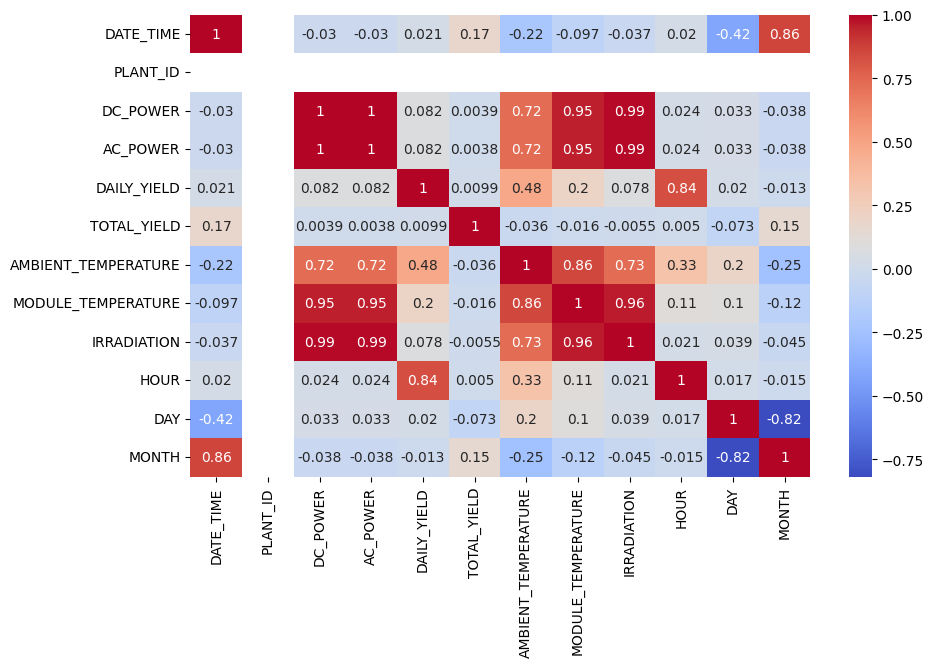

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(merged_data.corr(), annot=True, cmap='coolwarm')
plt.show()

What to observe:
Which features affect AC_POWER

Look for:

High positive values → strong relation

Negative values → inverse relation

5.2 Solar Power vs Time

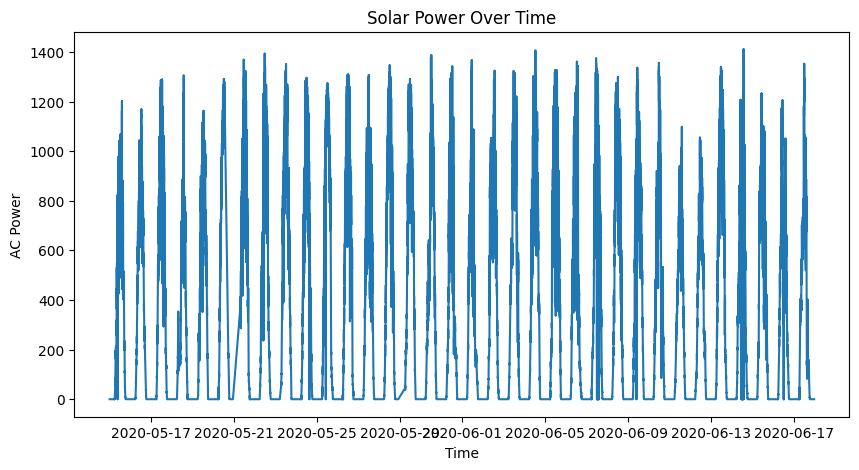

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(merged_data['DATE_TIME'], merged_data['AC_POWER'])
plt.title("Solar Power Over Time")
plt.xlabel("Time")
plt.ylabel("AC Power")
plt.show()

 5.3 Radiation vs Power

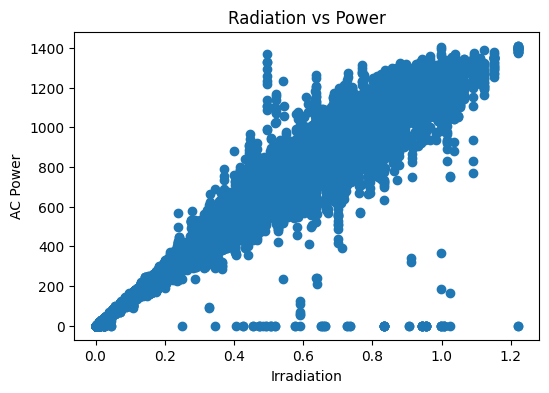

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(merged_data['IRRADIATION'], merged_data['AC_POWER'])
plt.xlabel("Irradiation")
plt.ylabel("AC Power")
plt.title("Radiation vs Power")
plt.show()

 5.4 Temperature vs Power

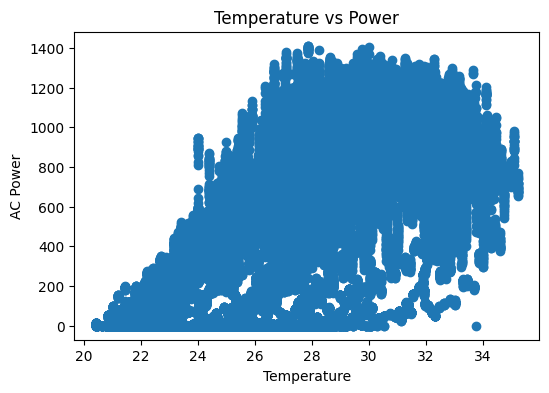

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(merged_data['AMBIENT_TEMPERATURE'], merged_data['AC_POWER'])
plt.xlabel("Temperature")
plt.ylabel("AC Power")
plt.title("Temperature vs Power")
plt.show()

STEP 6: Data Visualization (Using BI Tools)

 STEP 6.1: Export Cleaned Data from Colab

In [ ]:
merged_data.to_csv('cleaned_solar_data.csv', index=False)

In [18]:
from google.colab import files
files.download('cleaned_solar_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
print(merged_data['IRRADIATION'].unique())

[0.00000000e+00 8.62721241e-04 5.88695719e-03 ... 2.34457015e-02
 7.00688981e-03 3.90831153e-05]


In [20]:
merged_data['IRRADIATION'] = merged_data['IRRADIATION'] * 1000

In [21]:
merged_data.to_csv('cleaned_solar_data.csv', index=False)

In [22]:
from google.colab import files
files.download('cleaned_solar_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:
from google.colab import files
uploaded = files.upload()

Saving Screenshot 2026-04-06 232825.png to Screenshot 2026-04-06 232825.png
Saving Screenshot 2026-04-06 232859.png to Screenshot 2026-04-06 232859.png
Saving Screenshot 2026-04-06 232932.png to Screenshot 2026-04-06 232932.png


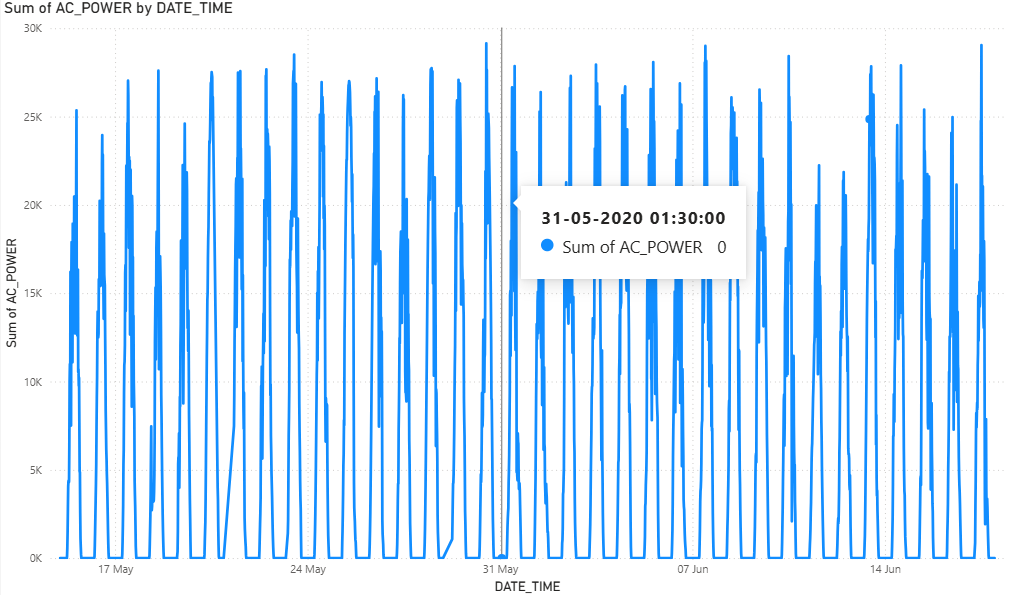

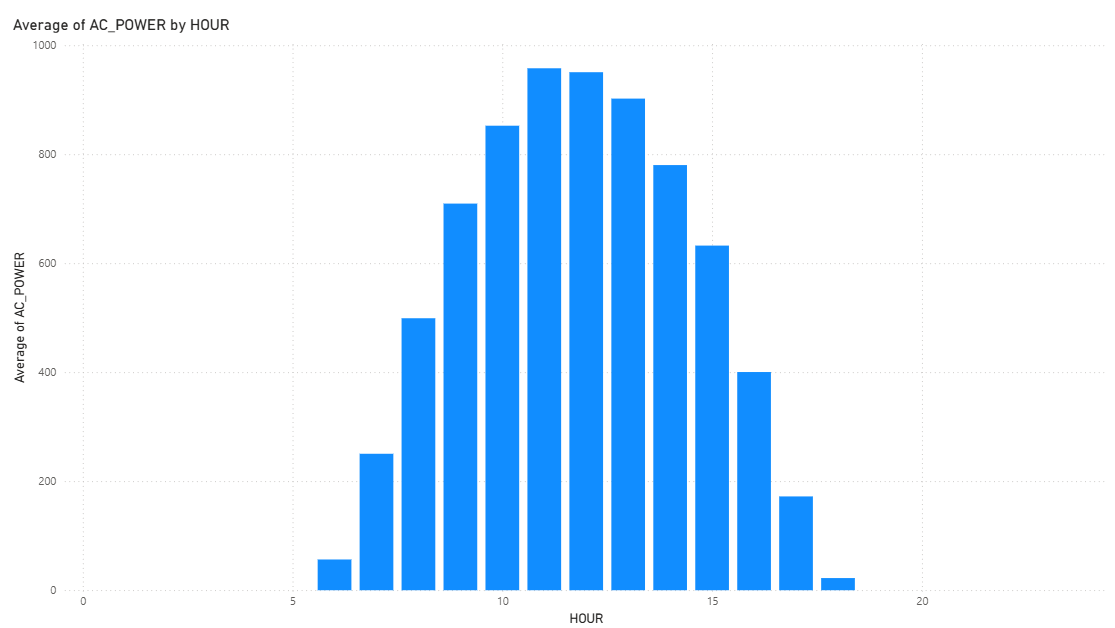

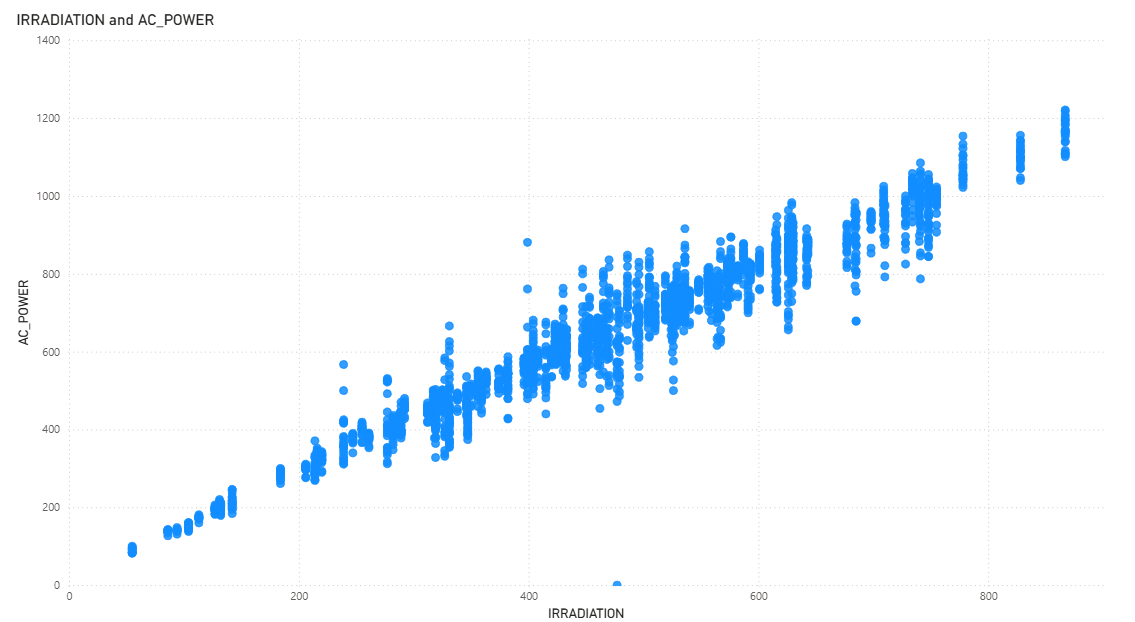

In [29]:
from IPython.display import Image, display

display(Image('Screenshot 2026-04-06 232825.png'))
display(Image('Screenshot 2026-04-06 232859.png'))
display(Image('Screenshot 2026-04-06 232932.png'))

STEP 7: Model Development (Machine Learning)
 STEP 7.1: Prepare Data

In [23]:
# Select features
X = merged_data[['IRRADIATION', 'AMBIENT_TEMPERATURE', 'HOUR']]

# Target
y = merged_data['AC_POWER']

STEP 7.2: Train-Test Split

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
    )

STEP 7.3: Train Model (Random Forest )

In [25]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_train, y_train)

RandomForestRegressor()

STEP 7.4: Predictions

In [26]:
y_pred = model.predict(X_test)

 STEP 7.5: Evaluate Model

In [27]:
from sklearn.metrics import r2_score, mean_absolute_error

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 Score: 0.9865945710526105
MAE: 16.339242961316085


 Loaded and explored the food waste dataset
 Cleaned the data (handled missing values, duplicates)
 Performed Exploratory Data Analysis (EDA) with visualizations
 Engineered features (converted text to numbers, extracted time features)
 Trained 3 different models (Linear Regression, Decision Tree, Random Forest)
 Compared model performance using MAE, RMSE, and R²
 Visualized predictions vs actual values
 Analyzed feature importance
 Saved the best model for future use
How Restaurants Can Use This Model:
Predict daily waste based on meal type, food category, and other factors
Plan better: Order less food on days with predicted high waste
Save money: Reduce food waste = reduce cost loss
Help environment: Less food waste = better sustainability
Possible Improvements:
Try more advanced models (XGBoost, Gradient Boosting)
Hyperparameter tuning
Add more features (weather, holidays, special events)
Deploy as a web app for real-time predictions